Dataset grezzo: 25646 righe × 208 colonne

--- score_UCLA ---
count   24825.00
mean        5.00
std         1.85
min         3.00
25%         3.00
50%         5.00
75%         6.00
max         9.00
Name: score_UCLA, dtype: float64
Missing: 821 (3.2%)

--- intensita_sm ---
intensita_sm
0     331
1    2506
2    3488
3    5619
4    4796
5    4229
6    2688
7    1183
8     806
Name: count, dtype: int64

Media: 3.80
Missing: 0

--- Distribuzione fasce d'età ---
fascia_eta
16–34     7572
35–54    11257
55+       6802
Name: count, dtype: int64

--- Missing variabili di controllo ---
  gender              : 80 (0.3%)
  education           : 162 (0.6%)
  income_decile       : 1956 (7.6%)

--- Listwise deletion ---
Righe prima : 25646
Righe dopo  : 22962
Rimosse     : 2684 (10.5%)

--- Filtro non-utenti ---
Righe prima del filtro : 22962
Righe dopo il filtro   : 22848
Non-utenti rimossi     : 114 (0.50%)

=== DataFrame finale ===
Shape: (22848, 8)
Paesi presenti: 27

Anteprima:
   paese  intensi

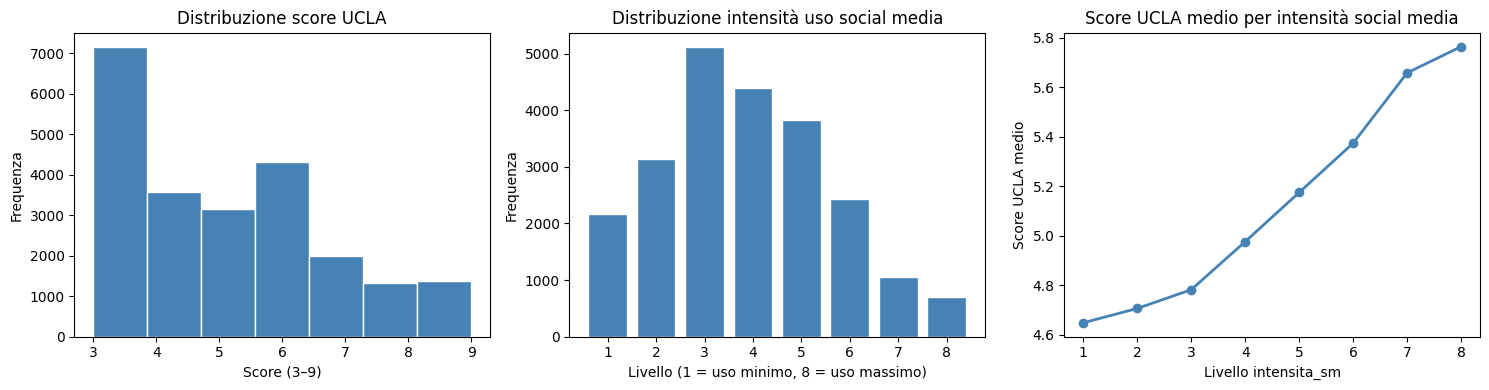


Salvato: output/dataset/eu_ls_clean.csv
Salvato: output/figures/step1_diagnostici.png


In [1]:
# ============================================================
# STEP 1 - Caricamento, pulizia e preparazione EU-LS 2022
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
 
os.makedirs('output/dataset', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
 
# ------------------------------------------------------------------
# 1.1 - CARICAMENTO
# ------------------------------------------------------------------
# Carica il CSV grezzo dell'EU-LS 2022 (25.646 righe x 208 colonne)
df_raw = pd.read_csv('eu_loneliness_survey_eu27_values.csv', low_memory=False)
print(f"Dataset grezzo: {df_raw.shape[0]} righe × {df_raw.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 1.2 - SELEZIONE COLONNE DI INTERESSE
# ------------------------------------------------------------------
# Selezioniamo solo le 9 colonne necessarie per l'analisi
COLS = ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c',
        'sm_time_a', 'country', 'age', 'gender', 'education', 'income_decile']
 
df = df_raw[COLS].copy()
 
# ------------------------------------------------------------------
# 1.3 - COSTRUZIONE "score_UCLA"
# ------------------------------------------------------------------
for col in ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c']:
    df[col] = df[col].replace(999, np.nan)
 
# Somma i 3 item UCLA; min_count=3 rende lo score valido solo se tutti e tre sono presenti
df['score_UCLA'] = df[['loneliness_ucla_a',
                        'loneliness_ucla_b',
                        'loneliness_ucla_c']].sum(axis=1, min_count=3)
 
print("\n--- score_UCLA ---")
print(df['score_UCLA'].describe().round(2))
print(f"Missing: {df['score_UCLA'].isna().sum()} ({df['score_UCLA'].isna().mean()*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.4 - COSTRUZIONE intensita_sm
# ------------------------------------------------------------------
# Per sm_time_a il codice 999 indica "non uso i social": lo mappiamo a 0 temporaneamente (i non-utenti verranno filtrati al passo 1.7b)
df['intensita_sm'] = df['sm_time_a'].replace(999, 0)
 
print("\n--- intensita_sm ---")
print(df['intensita_sm'].value_counts().sort_index())
print(f"\nMedia: {df['intensita_sm'].mean():.2f}")
print(f"Missing: {df['intensita_sm'].isna().sum()}")
 
# ------------------------------------------------------------------
# 1.5 - COSTRUZIONE fascia_eta - 3 FASCE
# La fascia 75+ è troppo piccola per confronti robusti. 
# Le due fasce anziane vengono accorpate in "55+", omogenea alle altre.
# La distinzione teorica rimane: nativi digitali (16–34), 
# generazione di transizione (35–54), pre-digitali (55+).
# ------------------------------------------------------------------
# 3 fasce: 16-34 nativi digitali, 35-54 generazione di transizione, 55+ pre-digitali
bins   = [15, 34, 54, 120]
labels = ['16–34', '35–54', '55+']
 
df['fascia_eta'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
 
print("\n--- Distribuzione fasce d'età ---")
print(df['fascia_eta'].value_counts().sort_index())
 
# ------------------------------------------------------------------
# 1.6 - PULIZIA VARIABILI DI CONTROLLO
# ------------------------------------------------------------------
for col in ['gender', 'education', 'income_decile']:
    df[col] = df[col].replace(999, np.nan)
 
print("\n--- Missing variabili di controllo ---")
for col in ['gender', 'education', 'income_decile']:
    n = df[col].isna().sum()
    print(f"  {col:20s}: {n} ({n/len(df)*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.7 - LISTWISE DELETION
# ------------------------------------------------------------------
# Rimuoviamo le righe con almeno un missing tra le variabili del modello (listwise deletion)
COLONNE_MODELLO = ['score_UCLA', 'intensita_sm', 'age', 'fascia_eta',
                   'gender', 'education', 'income_decile', 'country']
 
n_prima   = len(df)
df_clean  = df.dropna(subset=COLONNE_MODELLO).copy()
n_dopo    = len(df_clean)
 
print(f"\n--- Listwise deletion ---")
print(f"Righe prima : {n_prima}")
print(f"Righe dopo  : {n_dopo}")
print(f"Rimosse     : {n_prima - n_dopo} ({(n_prima - n_dopo)/n_prima*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.7b - FILTRO NON-UTENTI
# Il livello 0 (intensita_sm == 0, ≈331 persone nel raw, <1,5% del campione pulito) è gerarchicamente diverso dagli altri.
# I non-utenti non sono "utenti a bassa intensità": sono persone che non partecipano affatto 
# alla rete sociale digitale, per ragioni plausibilmente endogene alla solitudine (età avanzata,
# isolamento pre-esistente). Includerli produceva un punto a bassa numerosità sull'estremo sinistro 
# della distribuzione che trascinava la curva aggregata verso una pseudo-U-shape artificiale.
# ------------------------------------------------------------------
n_pre_filter = len(df_clean)
# Escludiamo i non-utenti (intensita_sm == 0): erano <1.5% del campione ma
# producevano una falsa U-shape nella curva aggregata e sono endogeni alla solitudine
df_clean = df_clean[df_clean['intensita_sm'] > 0].copy()
n_post_filter = len(df_clean)

print(f"\n--- Filtro non-utenti ---")
print(f"Righe prima del filtro : {n_pre_filter}")
print(f"Righe dopo il filtro   : {n_post_filter}")
print(f"Non-utenti rimossi     : {n_pre_filter - n_post_filter} "
      f"({(n_pre_filter - n_post_filter)/n_pre_filter*100:.2f}%)")

# ------------------------------------------------------------------
# 1.8 - DATAFRAME FINALE
# ------------------------------------------------------------------
# Selezioniamo e rinominiamo le colonne finali per maggiore chiarezza
COLONNE_FINALI = ['country', 'intensita_sm', 'score_UCLA',
                  'fascia_eta', 'age', 'gender', 'education', 'income_decile']
 
df_final = df_clean[COLONNE_FINALI].reset_index(drop=True)
df_final.columns = ['paese', 'intensita_sm', 'score_UCLA',
                    'fascia_eta', 'eta', 'sesso', 'education', 'income']
 
print("\n=== DataFrame finale ===")
print(f"Shape: {df_final.shape}")
print(f"Paesi presenti: {df_final['paese'].nunique()}")
print(f"\nAnteprima:\n{df_final.head(5)}")
 
# ------------------------------------------------------------------
# 1.9 - GRAFICI DIAGNOSTICI
# ------------------------------------------------------------------
# Tre grafici diagnostici: distribuzione UCLA, distribuzione intensita_sm,
# e score UCLA medio per livello SM (curva monotonicamente crescente dopo il filtro)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].hist(df_final['score_UCLA'], bins=7, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione score UCLA')
axes[0].set_xlabel('Score (3–9)')
axes[0].set_ylabel('Frequenza')
 
conteggi = df_final['intensita_sm'].value_counts().sort_index()
axes[1].bar(conteggi.index, conteggi.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuzione intensità uso social media')
axes[1].set_xlabel('Livello (1 = uso minimo, 8 = uso massimo)')
axes[1].set_ylabel('Frequenza')
axes[1].set_xticks(range(1, 9))

medie_globali = df_final.groupby('intensita_sm')['score_UCLA'].mean()
axes[2].plot(medie_globali.index, medie_globali.values,
             marker='o', color='steelblue', linewidth=2)
axes[2].set_title('Score UCLA medio per intensità social media')
axes[2].set_xlabel('Livello intensita_sm')
axes[2].set_ylabel('Score UCLA medio')
axes[2].set_xticks(range(1, 9))
 
plt.tight_layout()
fig.savefig('output/figures/step1_diagnostici.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 1.10 - SALVATAGGIO
# ------------------------------------------------------------------
# Salviamo il dataset pulito per ricaricarlo nelle celle successive
df_final.to_csv('output/dataset/eu_ls_clean.csv', index=False)
print("\nSalvato: output/dataset/eu_ls_clean.csv")
print("Salvato: output/figures/step1_diagnostici.png")

Dataset: 22848 righe × 8 colonne

=== Statistiche per fascia d'età ===
                n  ucla_media  ucla_std  sm_media  sm_std
fascia_eta                                               
16–34        6502        5.41      1.83      4.62    1.69
35–54       10153        5.04      1.87      3.80    1.69
55+          6193        4.50      1.73      3.15    1.64

=== Statistiche per paese (ordinato per UCLA medio) ===
          n  ucla_media  sm_media
paese                            
18      321        5.47      4.39
8       880        5.37      4.00
14      901        5.35      4.27
19      444        5.34      4.50
12      916        5.33      4.25
24      914        5.27      3.89
9       889        5.11      3.77
16      852        5.10      4.01
27      885        5.08      3.78
4       913        5.06      3.83
25      907        5.06      3.60
6       902        5.04      3.58
1       874        5.04      3.33
5       448        5.03      4.38
11     1023        5.00      3.28
2   

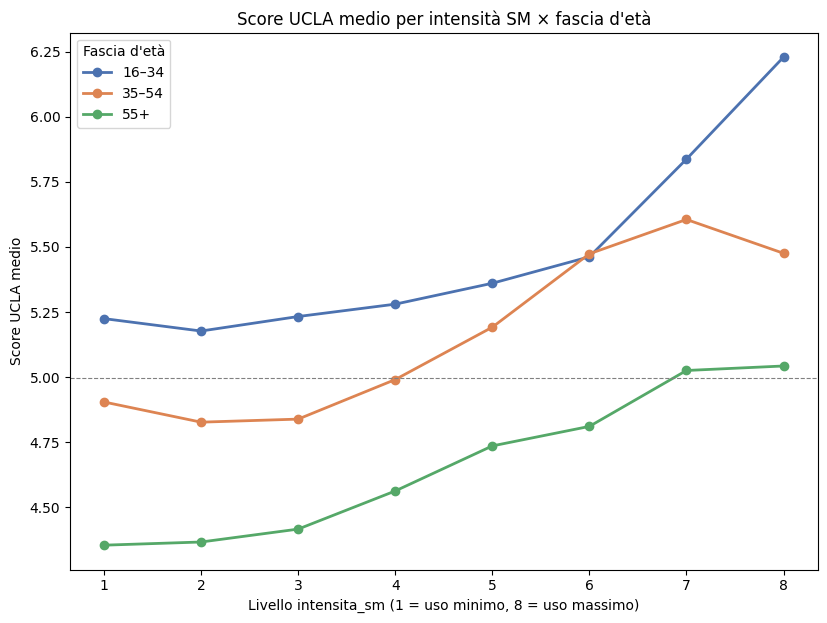


=== Riepilogo EDA ===
Score UCLA medio globale       : 5.00
Intensita_sm media globale     : 3.86
Correlazione Pearson globale   : r = 0.160 (p = 0.0000)
Correlazione Spearman globale  : r = 0.164 (p = 0.0000)

Fascia con UCLA più alto       : 16–34
Fascia con UCLA più basso      : 55+
Fascia con SM più intenso      : 16–34
Fascia con SM meno intenso     : 55+


In [2]:
# ============================================================
# STEP 2 - Analisi esplorativa (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
pd.set_option('display.float_format', '{:.2f}'.format)
 
# ------------------------------------------------------------------
# 2.1 - CARICAMENTO
# ------------------------------------------------------------------
# Ricarichiamo il dataset pulito; fascia_eta viene ricostruita come Categorical
# ordinata per garantire l'ordinamento corretto nei groupby e nei grafici
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
print(f"Dataset: {df.shape[0]} righe × {df.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 2.2 - STATISTICHE DESCRITTIVE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
# Statistiche per fascia: i giovani sono i piu' soli e i piu' intensi nell'uso SM
desc = df.groupby('fascia_eta', observed=True).agg(
    n           = ('score_UCLA', 'count'),
    ucla_media  = ('score_UCLA', 'mean'),
    ucla_std    = ('score_UCLA', 'std'),
    sm_media    = ('intensita_sm', 'mean'),
    sm_std      = ('intensita_sm', 'std'),
).round(2)
 
print("\n=== Statistiche per fascia d'età ===")
print(desc)
 
# ------------------------------------------------------------------
# 2.3 - STATISTICHE DESCRITTIVE PER PAESE
# ------------------------------------------------------------------
# Statistiche per paese: utili per valutare l'eterogeneita geografica
desc_paese = df.groupby('paese', observed=True).agg(
    n          = ('score_UCLA', 'count'),
    ucla_media = ('score_UCLA', 'mean'),
    sm_media   = ('intensita_sm', 'mean'),
).round(2).sort_values('ucla_media', ascending=False)
 
print("\n=== Statistiche per paese (ordinato per UCLA medio) ===")
print(desc_paese)
 
# ------------------------------------------------------------------
# 2.4 - CORRELAZIONE BIVARIATA - tutto il campione
# ------------------------------------------------------------------
# Correlazione globale: r~+0.16 (p<0.001). Segnale presente ma debole;
# i confondenti strutturali richiedono il passaggio all'OLS multivariato
pearson_r,  pearson_p  = stats.pearsonr(df['intensita_sm'], df['score_UCLA'])
spearman_r, spearman_p = stats.spearmanr(df['intensita_sm'], df['score_UCLA'])
 
print("\n=== Correlazione bivariata (tutto il campione) ===")
print(f"Pearson  r = {pearson_r:.3f}  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.3f}  p = {spearman_p:.4f}")
 
# ------------------------------------------------------------------
# 2.5 - CORRELAZIONE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
print("\n=== Correlazione Pearson per fascia d'età ===")
# Correlazione per fascia: valori simili tra fasce (r~0.10-0.12),
# la sola EDA non distingue il gradiente e serve il modello multivariato
corr_per_fascia = []
for fascia in ['16–34', '35–54', '55+']:
    sub = df[df['fascia_eta'] == fascia]
    r, p = stats.pearsonr(sub['intensita_sm'], sub['score_UCLA'])
    corr_per_fascia.append({'fascia': fascia, 'n': len(sub),
                            'pearson_r': round(r, 3), 'p_value': round(p, 4)})
    print(f"  {fascia:6s}  r = {r:.3f}  p = {p:.4f}  (n={len(sub)})")
 
# ------------------------------------------------------------------
# 2.6 - GRAFICI EDA
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))
 
# Line plot UCLA medio per livello intensita_sm × fascia d'età
ax2 = fig.add_subplot(2, 2, 2)
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}  
for fascia in ['16–34', '35–54', '55+']:                              
    sub   = df[df['fascia_eta'] == fascia]
    medie = sub.groupby('intensita_sm')['score_UCLA'].mean()
    ax2.plot(medie.index, medie.values, marker='o', linewidth=2,
             label=fascia, color=colori[fascia])
ax2.set_title("Score UCLA medio per intensità SM × fascia d'età")
ax2.set_xlabel('Livello intensita_sm (1 = uso minimo, 8 = uso massimo)')
ax2.set_ylabel('Score UCLA medio')
ax2.set_xticks(range(1, 9))
ax2.legend(title="Fascia d'età")
ax2.axhline(df['score_UCLA'].mean(), color='gray',
            linestyle='--', linewidth=0.8, label='Media globale')

plt.suptitle('')
 
plt.tight_layout()
fig.savefig('output/figures/step2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 2.7 - RIEPILOGO RISULTATI EDA
# ------------------------------------------------------------------
print("\n=== Riepilogo EDA ===")
print(f"Score UCLA medio globale       : {df['score_UCLA'].mean():.2f}")
print(f"Intensita_sm media globale     : {df['intensita_sm'].mean():.2f}")
print(f"Correlazione Pearson globale   : r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"Correlazione Spearman globale  : r = {spearman_r:.3f} (p = {spearman_p:.4f})")
print("\nFascia con UCLA più alto       :", desc['ucla_media'].idxmax())
print("Fascia con UCLA più basso      :", desc['ucla_media'].idxmin())
print("Fascia con SM più intenso      :", desc['sm_media'].idxmax())
print("Fascia con SM meno intenso     :", desc['sm_media'].idxmin())

Dataset: 22848 righe · 27 paesi
Range intensita_sm: 1–8

3.2a  ROBUSTNESS CHECK — termine quadratico sul campione filtrato

Tutto il campione  N=22848  R²=0.0699
  β₂ (intensita_sm²) = +0.0111  p = 0.0013  **

Per fascia:
  16–34   N= 6502  β₂=+0.0297  p=0.0000  ***
  35–54   N=10153  β₂=+0.0119  p=0.0302  *
  55+     N= 6193  β₂=+0.0091  p=0.1701  n.s.

→ Se β₂ non è più significativo in nessuna fascia, la U-shape
  era un artefatto del livello 0. Passiamo al modello lineare.

3.2b  OLS LINEARE — tutto il campione
N = 22848  |  R² = 0.0694  |  R² adj = 0.0682

Coefficienti chiave:
  Intercept       β=+4.7855  SE=0.0884  p=0.0000  CI=[+4.6122, +4.9587]  ***
  intensita_sm    β=+0.1573  SE=0.0072  p=0.0000  CI=[+0.1432, +0.1714]  ***
  sesso           β=+0.1738  SE=0.0238  p=0.0000  CI=[+0.1271, +0.2205]  ***
  education       β=+0.0022  SE=0.0146  p=0.8827  CI=[-0.0264, +0.0307]  n.s.
  income          β=-0.1158  SE=0.0049  p=0.0000  CI=[-0.1253, -0.1062]  ***

=== OLS lineare — per fa

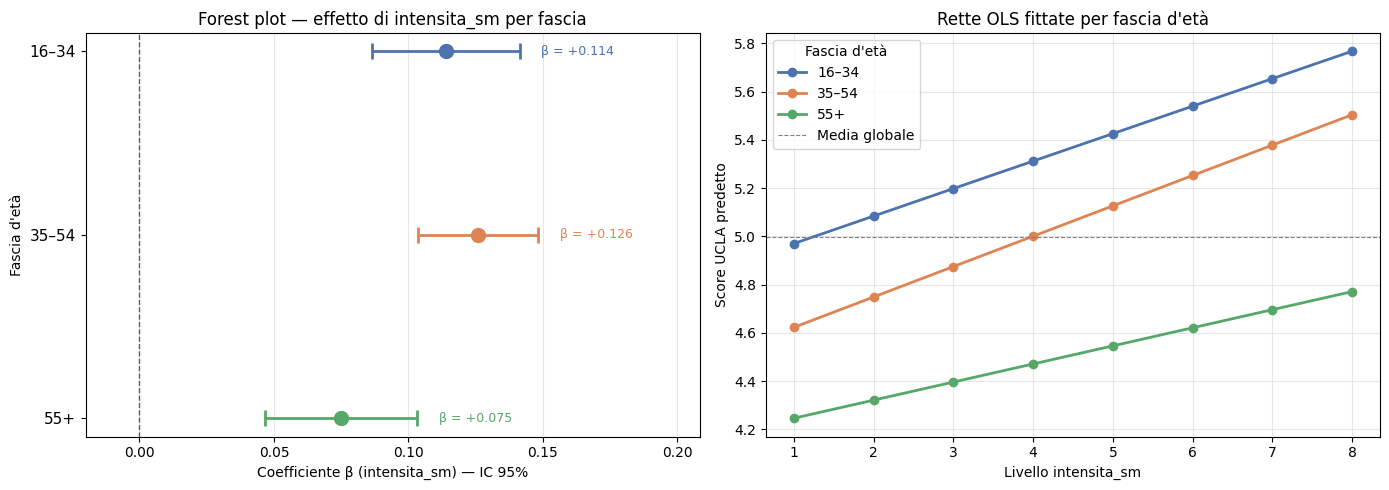

Salvato: output/figures/step3_ols.png
3.7  Analisi di sensibilità — non-linearità nella fascia 16–34

Modello lineare       — R² = 0.0620
Modello quadratico    — R² = 0.0652
ΔR² (quadratico − lineare) = 0.0032 (0.32%)

F-test contributo intensita_sm²:
  F(1, 6470.0) = 22.02    p = 0.000003

Coefficienti modello quadratico (16–34):
  intensita_sm     β₁ = -0.1584  p = 0.0118  *
  intensita_sm²    β₂ = +0.0297  p = 0.0000  ***


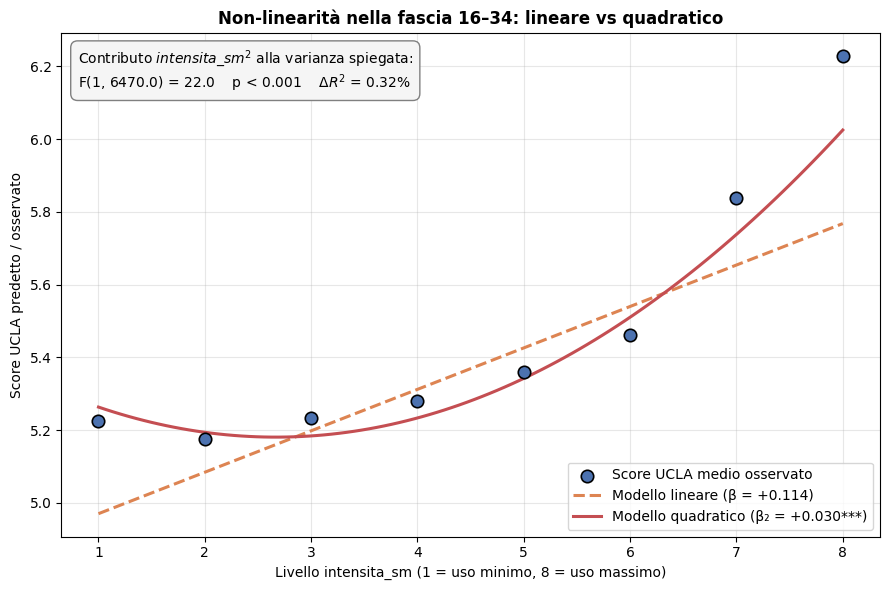


Salvato: output/figures/step3_nonlinearita_giovani.png


In [3]:
# ============================================================
# STEP 3 - Regressione OLS (campione utenti, modello lineare)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option('display.float_format', '{:.4f}'.format)

# ------------------------------------------------------------------
# 3.1 - CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],
                                   ordered=True)
# Termine quadratico: usato nel robustness check (3.2a) e nell'analisi
# di sensibilita per la fascia 16-34 (3.7)
df['intensita_sm2'] = df['intensita_sm'] ** 2

fasce  = ['16–34', '35–54', '55+']
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}

print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
print(f"Range intensita_sm: {df['intensita_sm'].min()}–{df['intensita_sm'].max()}")

# Funzione di utilita': converte un p-value nel simbolo di significativita' standard
def stelle(p):
    return '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))

# ------------------------------------------------------------------
# 3.2a - ROBUSTNESS CHECK — il quadratico è ancora giustificato?
# Sul campione utenti (livelli 1–8) la U-shape aggregata scompare.
# Verifichiamo se β₂ è ancora significativo altrimenti lo rimuoviamo.
# ------------------------------------------------------------------
print("\n" + "="*70)
print("3.2a  ROBUSTNESS CHECK — termine quadratico sul campione filtrato")
print("="*70)

# Verifichiamo se il termine quadratico e' ancora necessario dopo aver rimosso i non-utenti.
# Se la U-shape era un artefatto del livello 0, beta_2 dovrebbe sparire
formula_quad = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                '+ sesso + education + income + C(paese)')

m_quad = smf.ols(formula_quad, data=df).fit(cov_type='HC3')
b2, p2 = m_quad.params['intensita_sm2'], m_quad.pvalues['intensita_sm2']
print(f"\nTutto il campione  N={int(m_quad.nobs)}  R²={m_quad.rsquared:.4f}")
print(f"  β₂ (intensita_sm²) = {b2:+.4f}  p = {p2:.4f}  {stelle(p2)}")

print("\nPer fascia:")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia]
    mq  = smf.ols(formula_quad, data=sub).fit(cov_type='HC3')
    b2f, p2f = mq.params['intensita_sm2'], mq.pvalues['intensita_sm2']
    print(f"  {fascia:6s}  N={int(mq.nobs):5d}  β₂={b2f:+.4f}  p={p2f:.4f}  {stelle(p2f)}")

print("\n→ Se β₂ non è più significativo in nessuna fascia, la U-shape")
print("  era un artefatto del livello 0. Passiamo al modello lineare.")

# ------------------------------------------------------------------
# 3.2b - MODELLO PRINCIPALE LINEARE su tutto il campione
# ------------------------------------------------------------------
# Il termine quadratico non incluso in quanto non piu necessario dopo il filtro
formula_lin = ('score_UCLA ~ intensita_sm '
               '+ sesso + education + income + C(paese)')

# Stima sul campione completo: utile come riferimento globale,
# ma non e' l'analisi principale (gli effetti per fascia si annullano parzialmente)
model_full = smf.ols(formula_lin, data=df).fit(cov_type='HC3')

print("\n" + "="*70)
print("3.2b  OLS LINEARE — tutto il campione")
print("="*70)
print(f"N = {int(model_full.nobs)}  |  R² = {model_full.rsquared:.4f}"
      f"  |  R² adj = {model_full.rsquared_adj:.4f}")
print(f"\nCoefficienti chiave:")
for k in ['Intercept', 'intensita_sm', 'sesso', 'education', 'income']:
    b      = model_full.params[k]
    se     = model_full.bse[k]
    p      = model_full.pvalues[k]
    ci_lo, ci_hi = model_full.conf_int().loc[k]
    print(f"  {k:14s}  β={b:+.4f}  SE={se:.4f}  p={p:.4f}  "
          f"CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]  {stelle(p)}")

# ------------------------------------------------------------------
# 3.3 - OLS LINEARE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
# Stima separata per 16-34, 35-54 e 55+.
# Il risultato chiave è beta positivo e significativo in tutte le fasce (p<0.001); il massimo e' in 35-54.
risultati = {}
print("\n=== OLS lineare — per fascia d'età ===")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    mod = smf.ols(formula_lin, data=sub).fit(cov_type='HC3')
    risultati[fascia] = mod

    b, se, p = mod.params['intensita_sm'], mod.bse['intensita_sm'], mod.pvalues['intensita_sm']
    ci_lo, ci_hi = mod.conf_int().loc['intensita_sm']
    print(f"\n  Fascia {fascia}  (N={int(mod.nobs)}, R²={mod.rsquared:.4f})")
    print(f"    intensita_sm   β={b:+.4f}  SE={se:.4f}  p={p:.4f}  "
          f"CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]  {stelle(p)}")

# ------------------------------------------------------------------
# 3.4 - TABELLA COMPARATIVA β PER FASCIA
# ------------------------------------------------------------------
# Costruiamo la tabella: beta, SE, IC 95%, p-value e R2 per ogni fascia
righe = []
for fascia in fasce:
    mod = risultati[fascia]
    righe.append({
        'fascia'   : fascia,
        'N'        : int(mod.nobs),
        'beta'     : round(mod.params['intensita_sm'], 4),
        'SE'       : round(mod.bse['intensita_sm'], 4),
        'p_value'  : round(mod.pvalues['intensita_sm'], 4),
        'CI_low'   : round(mod.conf_int().loc['intensita_sm', 0], 4),
        'CI_high'  : round(mod.conf_int().loc['intensita_sm', 1], 4),
        'R2'       : round(mod.rsquared, 4),
        'sig'      : stelle(mod.pvalues['intensita_sm'])
    })

tab = pd.DataFrame(righe)
print("\n=== Tabella comparativa β × fascia d'età ===")
print(tab.to_string(index=False))
tab.to_csv('output/dataset/step3_coefficienti.csv', index=False)
print("\nSalvato: output/dataset/step3_coefficienti.csv")

# ------------------------------------------------------------------
# 3.5 - VERIFICA H₀ / H₁
# ------------------------------------------------------------------
# Verifica esplicita di H0 e H1 per ogni fascia d'eta
print("\n=== Verifica ipotesi ===")
print("H₀: intensita_sm non associata a score_UCLA in nessuna fascia")
print("H₁: associazione presente e variabile per fascia d'età\n")
for r in righe:
    esito = (f"→ associazione PRESENTE (contro H₀)"
             if r['p_value'] < 0.05
             else "→ associazione ASSENTE (a favore H₀)")
    print(f"  {r['fascia']:6s}  β={r['beta']:+.4f}  p={r['p_value']:.4f} "
          f"{r['sig']:4s}  {esito}")

# ------------------------------------------------------------------
# 3.6 - GRAFICI
# ------------------------------------------------------------------
# Figura con forest plot dei beta (sinistra) e rette OLS fittate per fascia (destra)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig A: forest plot β per fascia con IC 95%
betas  = [risultati[f].params['intensita_sm'] for f in fasce]
ci_lo  = [risultati[f].conf_int().loc['intensita_sm', 0] for f in fasce]
ci_hi  = [risultati[f].conf_int().loc['intensita_sm', 1] for f in fasce]
ys     = np.arange(len(fasce))[::-1]   # 16-34 in alto, 55+ in basso

# Linea di riferimento β=0
axes[0].axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)

# Errorbar orizzontali (IC 95%) + punti
for i, fascia in enumerate(fasce):
    axes[0].errorbar(betas[i], ys[i],
                     xerr=[[betas[i] - ci_lo[i]], [ci_hi[i] - betas[i]]],
                     fmt='o', markersize=10, capsize=6, capthick=2,
                     color=colori[fascia], ecolor=colori[fascia],
                     elinewidth=2, label=fascia)
    # Annotazione del valore β a destra del CI
    axes[0].text(ci_hi[i] + 0.008, ys[i],
                 f'β = {betas[i]:+.3f}',
                 va='center', fontsize=9, color=colori[fascia])

axes[0].set_yticks(ys)
axes[0].set_yticklabels(fasce, fontsize=11)
axes[0].set_xlabel('Coefficiente β (intensita_sm) — IC 95%')
axes[0].set_ylabel("Fascia d'età")
axes[0].set_title("Forest plot — effetto di intensita_sm per fascia")
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(-0.02, max(ci_hi) + 0.06)

# Fig B: rette fitted per fascia
sm_range = np.arange(1, 9)
for fascia in fasce:
    mod = risultati[fascia]
    b0  = mod.params['Intercept']
    b1  = mod.params['intensita_sm']
    sub = df[df['fascia_eta'] == fascia]
    adj = (mod.params.get('sesso', 0)     * sub['sesso'].mean() +
           mod.params.get('education', 0) * sub['education'].mean() +
           mod.params.get('income', 0)    * sub['income'].mean())
    y_pred = b0 + b1*sm_range + adj
    axes[1].plot(sm_range, y_pred, linewidth=2,
                 label=fascia, color=colori[fascia], marker='o')

axes[1].axhline(df['score_UCLA'].mean(), color='gray',
                linestyle='--', linewidth=0.8, label='Media globale')
axes[1].set_title("Rette OLS fittate per fascia d'età")
axes[1].set_xlabel('Livello intensita_sm')
axes[1].set_ylabel('Score UCLA predetto')
axes[1].set_xticks(range(1, 9))
axes[1].legend(title="Fascia d'età")
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig('output/figures/step3_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step3_ols.png")

# ============================================================
# 3.7 - ANALISI DI SENSIBILITÀ (non-linearità nella fascia 16–34)
# ============================================================

# Analisi di sensibilita' solo per la fascia 16-34, dove l'EDA mostra un'accelerazione visibile ai livelli 6-8
sub_giovani = df[df['fascia_eta'] == '16–34'].copy()

formula_quad_16_34 = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                       '+ sesso + education + income + C(paese)')
mod_quad_16_34 = smf.ols(formula_quad_16_34, data=sub_giovani).fit(cov_type='HC3')

# F-test: contributo incrementale del quadratico nella sola fascia 16–34
formula_lin_16_34 = ('score_UCLA ~ intensita_sm '
                      '+ sesso + education + income + C(paese)')
mod_lin_16_34 = smf.ols(formula_lin_16_34, data=sub_giovani).fit(cov_type='HC3')

# F-test per il contributo incrementale del termine quadratico
r2_lin  = mod_lin_16_34.rsquared
r2_quad = mod_quad_16_34.rsquared
delta_r2 = r2_quad - r2_lin

n      = int(mod_quad_16_34.nobs)
k_quad = mod_quad_16_34.df_model
f_stat = ((r2_quad - r2_lin) / 1) / ((1 - r2_quad) / (n - k_quad - 1))
f_pval = 1 - stats.f.cdf(f_stat, 1, n - k_quad - 1)

print("="*70)
print("3.7  Analisi di sensibilità — non-linearità nella fascia 16–34")
print("="*70)
print(f"\nModello lineare       — R² = {r2_lin:.4f}")
print(f"Modello quadratico    — R² = {r2_quad:.4f}")
print(f"ΔR² (quadratico − lineare) = {delta_r2:.4f} ({delta_r2*100:.2f}%)")
print(f"\nF-test contributo intensita_sm²:")
print(f"  F(1, {n - k_quad - 1}) = {f_stat:.2f}    p = {f_pval:.6f}")
print(f"\nCoefficienti modello quadratico (16–34):")
b1q = mod_quad_16_34.params['intensita_sm']
b2q = mod_quad_16_34.params['intensita_sm2']
p1q = mod_quad_16_34.pvalues['intensita_sm']
p2q = mod_quad_16_34.pvalues['intensita_sm2']
print(f"  intensita_sm     β₁ = {b1q:+.4f}  p = {p1q:.4f}  {stelle(p1q)}")
print(f"  intensita_sm²    β₂ = {b2q:+.4f}  p = {p2q:.4f}  {stelle(p2q)}")

fig, ax = plt.subplots(figsize=(9, 6))

# Figura dei punti osservati + retta lineare + curva quadratica per la fascia 16-34
medie_obs = sub_giovani.groupby('intensita_sm')['score_UCLA'].mean()
ax.scatter(medie_obs.index, medie_obs.values,
           s=80, color='#4C72B0', edgecolor='black', linewidth=1.2,
           zorder=3, label='Score UCLA medio osservato')

# Predizione lineare (modello principale per 16–34)
mod_lin_16_34_principale = risultati['16–34']  # già stimato nella sezione 3.3
b0_lin = mod_lin_16_34_principale.params['Intercept']
b1_lin = mod_lin_16_34_principale.params['intensita_sm']
adj_lin = (mod_lin_16_34_principale.params.get('sesso', 0)     * sub_giovani['sesso'].mean() +
           mod_lin_16_34_principale.params.get('education', 0) * sub_giovani['education'].mean() +
           mod_lin_16_34_principale.params.get('income', 0)    * sub_giovani['income'].mean())

sm_grid = np.linspace(1, 8, 100)
y_lin   = b0_lin + b1_lin * sm_grid + adj_lin
ax.plot(sm_grid, y_lin, linewidth=2.2, linestyle='--',
        color='#DD8452', label='Modello lineare (β = +0.114)')

# Predizione quadratica
b0_q = mod_quad_16_34.params['Intercept']
b1_q = mod_quad_16_34.params['intensita_sm']
b2_q = mod_quad_16_34.params['intensita_sm2']
adj_q = (mod_quad_16_34.params.get('sesso', 0)     * sub_giovani['sesso'].mean() +
         mod_quad_16_34.params.get('education', 0) * sub_giovani['education'].mean() +
         mod_quad_16_34.params.get('income', 0)    * sub_giovani['income'].mean())

y_q = b0_q + b1_q * sm_grid + b2_q * sm_grid**2 + adj_q
ax.plot(sm_grid, y_q, linewidth=2.2, color='#C44E52',
        label=f'Modello quadratico (β₂ = {b2q:+.3f}***)')

# Annotazione F-test
ax.text(0.02, 0.97,
        f'Contributo $intensita\\_sm^2$ alla varianza spiegata:\n'
        f'F(1, {n - k_quad - 1}) = {f_stat:.1f}    p < 0.001    '
        f'$\\Delta R^2$ = {delta_r2*100:.2f}%',
        transform=ax.transAxes, va='top', ha='left',
        fontsize=10, bbox=dict(boxstyle='round,pad=0.5',
                                facecolor='#F5F5F5', edgecolor='gray'))

ax.set_title("Non-linearità nella fascia 16–34: lineare vs quadratico",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Livello intensita_sm (1 = uso minimo, 8 = uso massimo)')
ax.set_ylabel('Score UCLA predetto / osservato')
ax.set_xticks(range(1, 9))
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('output/figures/step3_nonlinearita_giovani.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nSalvato: output/figures/step3_nonlinearita_giovani.png")

Dataset: 22848 righe · 30 feature totali
Feature individuali: ['intensita_sm', 'sesso', 'education', 'income']


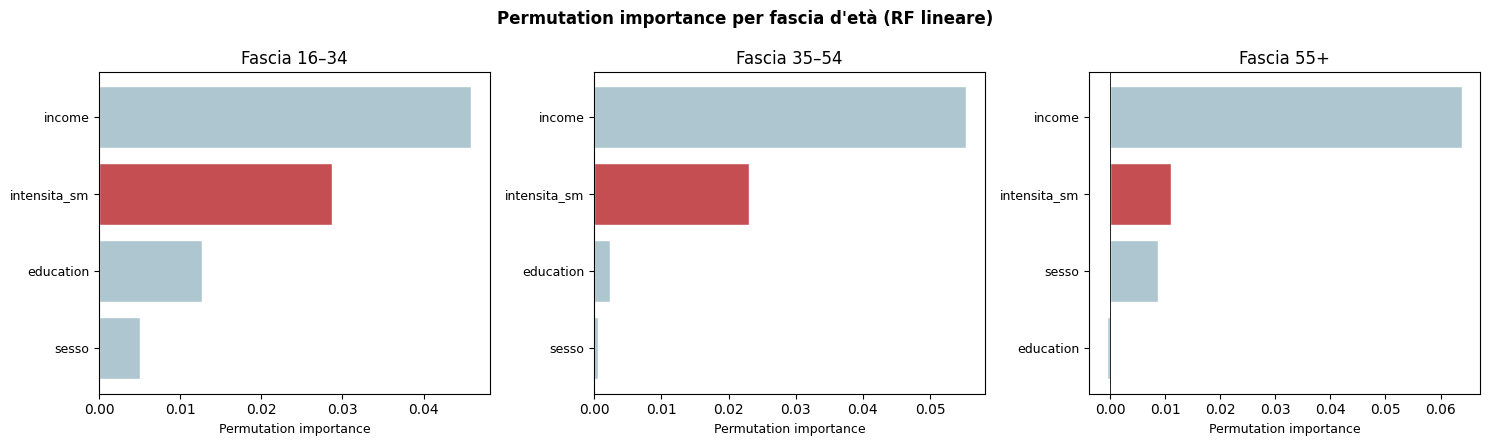

Salvato: output/figures/step4_rf_importance_fascia.png


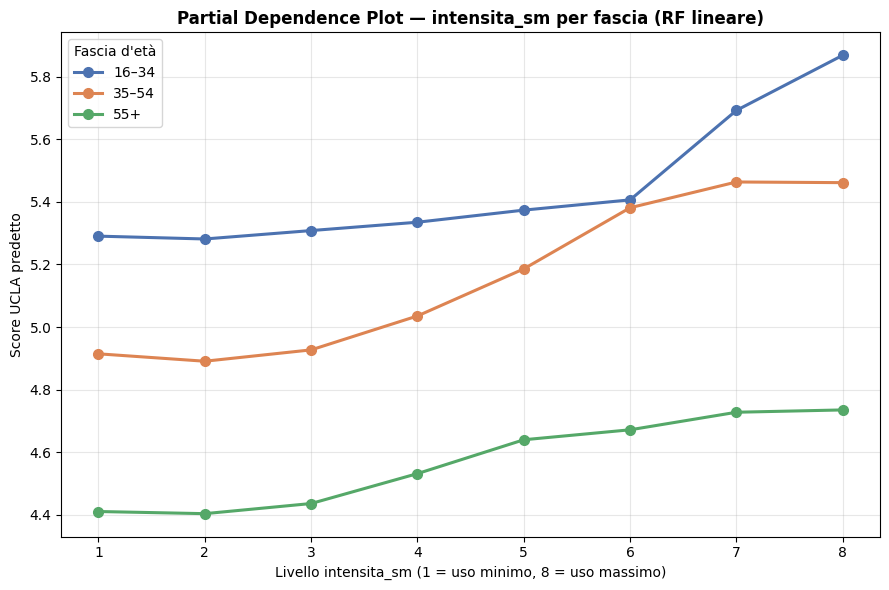

Salvato: output/figures/step4_rf_pdp.png  ← FIG. 4 DEL REPORT


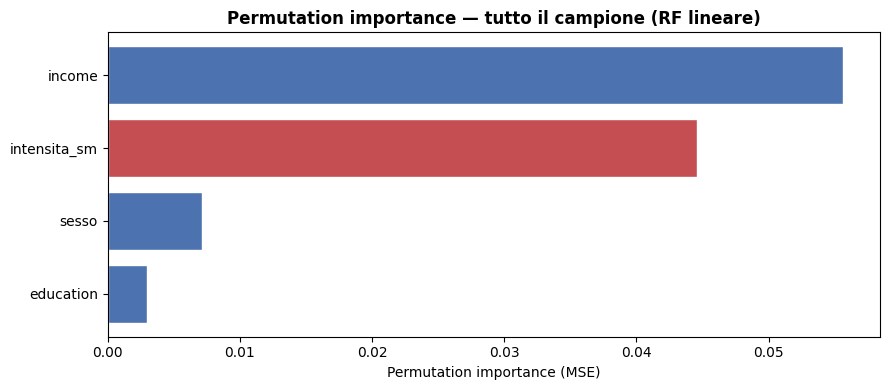

Salvato: output/figures/step4_rf_importance_full.png

RIEPILOGO STEP 4 — Feature Importance (RF lineare)

RF tutto il campione: MAE=1.5094  RMSE=1.7929

--- Metriche RF per fascia ---
  16–34   N_train=5201  N_test=1301  MAE=1.4710  RMSE=1.7531
  35–54   N_train=8122  N_test=2031  MAE=1.5331  RMSE=1.8199
  55+     N_train=4954  N_test=1239  MAE=1.4333  RMSE=1.7549

--- Permutation importance per fascia (top 5, esclusi paesi) ---

  Fascia 16–34  (intensita_sm rank #2):
    income                  0.0459
    intensita_sm            0.0287 ◄
    education               0.0127
    sesso                   0.0050

  Fascia 35–54  (intensita_sm rank #2):
    income                  0.0554
    intensita_sm            0.0230 ◄
    education               0.0024
    sesso                   0.0007

  Fascia 55+  (intensita_sm rank #2):
    income                  0.0639
    intensita_sm            0.0110 ◄
    sesso                   0.0087
    education               -0.0006

--- Importance tut

In [4]:
# ============================================================
# STEP 4 — Random Forest (ML supervisionato, modello lineare)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ------------------------------------------------------------------
# 4.1 - CARICAMENTO E PREPARAZIONE FEATURE
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                  categories=['16–34', '35–54', '55+'],
                                  ordered=True)

# Codifica il paese come 26 variabili dummy (drop_first=True), stesso approccio delle dummies nell'OLS
paese_dummies = pd.get_dummies(df['paese'], prefix='paese', drop_first=True)

# Feature set del modello lineare principale
FEATURES = ['intensita_sm', 'sesso', 'education', 'income']
X_base   = pd.concat([df[FEATURES], paese_dummies], axis=1).astype(float)
y        = df['score_UCLA']

fasce  = ['16–34', '35–54', '55+']
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}

print(f"Dataset: {df.shape[0]} righe · {X_base.shape[1]} feature totali")
print(f"Feature individuali: {FEATURES}")

# ------------------------------------------------------------------
# 4.2 - MODELLO RF SU TUTTO IL CAMPIONE
# ------------------------------------------------------------------
# Split 80/20 con seed fisso per riproducibilita.
# Il modello full serve per le metriche globali e la importance aggregata
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_base, y, test_size=0.20, random_state=42)

# 200 alberi, max_features=sqrt, min_samples_leaf=20 per regolarizzare su dati survey
rf_full = RandomForestRegressor(
    n_estimators=200, max_features='sqrt',
    min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_full.fit(X_tr_full, y_tr_full)

mae_full  = mean_absolute_error(y_te_full, rf_full.predict(X_te_full))
rmse_full = np.sqrt(mean_squared_error(y_te_full, rf_full.predict(X_te_full)))

# ------------------------------------------------------------------
# 4.3 - MODELLO RF PER FASCIA
# ------------------------------------------------------------------
# Dizionari per raccogliere modelli e importance per ogni fascia d'eta
modelli  = {}
perm_imp = {}

for fascia in fasce:
    mask = df['fascia_eta'] == fascia
    X_f  = X_base[mask].reset_index(drop=True)
    y_f  = y[mask].reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_f, y_f, test_size=0.20, random_state=42)

    rf = RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    modelli[fascia] = (rf, X_tr, X_te, y_tr, y_te)

    # Misura quanto peggiora l'errore se una feature viene rimescolata sul test set (valore alto = feature informativa)
    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
    perm_imp[fascia] = pd.Series(perm.importances_mean, index=X_base.columns)

# Permutation importance globale (utile per il composito e per il salvataggio standalone)
perm_full = permutation_importance(
    rf_full, X_te_full, y_te_full, n_repeats=10, random_state=42, n_jobs=-1)
imp_full = pd.Series(perm_full.importances_mean, index=X_base.columns)
imp_individuale = imp_full[FEATURES].sort_values()

# ------------------------------------------------------------------
# 4.4 - GRAFICO STANDALONE - Permutation importance per fascia (3 pannelli)
# ------------------------------------------------------------------
# Grafico importance per fascia dove income e' primo in tutte le fasce e intensita_sm e' costantemente secondo
fig_imp_fascia, axes_imp = plt.subplots(1, 3, figsize=(15, 4.5))
fig_imp_fascia.suptitle("Permutation importance per fascia d'età (RF lineare)",
                        fontsize=12, fontweight='bold')

for ax, fascia in zip(axes_imp, fasce):
    top5 = perm_imp[fascia].drop(
        [c for c in perm_imp[fascia].index if c.startswith('paese_')]
    ).nlargest(5).sort_values()
    colors = ['#C44E52' if f == 'intensita_sm' else '#AEC6CF' for f in top5.index]
    ax.barh(top5.index, top5.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Fascia {fascia}')
    ax.set_xlabel('Permutation importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
fig_imp_fascia.savefig('output/figures/step4_rf_importance_fascia.png',
                       dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_rf_importance_fascia.png")

# ------------------------------------------------------------------
# 4.5 - GRAFICO STANDALONE - Partial Dependence Plot per fascia
# ------------------------------------------------------------------
# Grafico PDP che mostra la relazione marginale tra intensita_sm e la predizione, mediando su tutte le altre feature.
fig_pdp, ax_pdp = plt.subplots(figsize=(9, 6))

for fascia in fasce:
    rf, _, X_te, _, _ = modelli[fascia]
    vals = []
    for v in range(1, 9):
        X_tmp = X_te.copy()
        X_tmp['intensita_sm'] = v
        vals.append(rf.predict(X_tmp).mean())
    ax_pdp.plot(range(1, 9), vals, marker='o',
                label=fascia, color=colori[fascia],
                linewidth=2.2, markersize=7)

ax_pdp.set_title("Partial Dependence Plot — intensita_sm per fascia (RF lineare)",
                 fontsize=12, fontweight='bold')
ax_pdp.set_xlabel('Livello intensita_sm (1 = uso minimo, 8 = uso massimo)')
ax_pdp.set_ylabel('Score UCLA predetto')
ax_pdp.set_xticks(range(1, 9))
ax_pdp.legend(title="Fascia d'età", fontsize=10)
ax_pdp.grid(alpha=0.3)

plt.tight_layout()
fig_pdp.savefig('output/figures/step4_rf_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_rf_pdp.png  ← FIG. 4 DEL REPORT")

# ------------------------------------------------------------------
# 4.6 - GRAFICO STANDALONE
# ------------------------------------------------------------------
# Grafico che mostra l'importance globale sul campione completo
fig_imp_full, ax_full = plt.subplots(figsize=(9, 4))

colors_all = ['#C44E52' if f == 'intensita_sm' else '#4C72B0'
              for f in imp_individuale.index]
ax_full.barh(imp_individuale.index, imp_individuale.values,
             color=colors_all, edgecolor='white')
ax_full.axvline(0, color='black', linewidth=0.6)
ax_full.set_title('Permutation importance — tutto il campione (RF lineare)',
                  fontsize=12, fontweight='bold')
ax_full.set_xlabel('Permutation importance (MSE)')

plt.tight_layout()
fig_imp_full.savefig('output/figures/step4_rf_importance_full.png',
                     dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_rf_importance_full.png")

# ------------------------------------------------------------------
# 4.8 - RIEPILOGO FINALE
# ------------------------------------------------------------------
print("\n" + "="*60)
print("RIEPILOGO STEP 4 — Feature Importance (RF lineare)")
print("="*60)

print(f"\nRF tutto il campione: MAE={mae_full:.4f}  RMSE={rmse_full:.4f}")

print("\n--- Metriche RF per fascia ---")
for fascia in fasce:
    rf, X_tr, X_te, y_tr, y_te = modelli[fascia]
    y_pred = rf.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f"  {fascia:6s}  N_train={len(X_tr):4d}  N_test={len(X_te):4d}  MAE={mae:.4f}  RMSE={rmse:.4f}")

print("\n--- Permutation importance per fascia (top 5, esclusi paesi) ---")
for fascia in fasce:
    imp_no_paese = perm_imp[fascia].drop(
        [c for c in perm_imp[fascia].index if c.startswith('paese_')]
    )
    top5 = imp_no_paese.nlargest(5)
    rank_sm = list(imp_no_paese.sort_values(ascending=False).index).index('intensita_sm') + 1
    print(f"\n  Fascia {fascia}  (intensita_sm rank #{rank_sm}):")
    for feat, val in top5.items():
        marker = " ◄" if feat == 'intensita_sm' else ""
        print(f"    {feat:22s}  {val:.4f}{marker}")

print("\n--- Importance tutto il campione ---")
for feat, val in imp_individuale.sort_values(ascending=False).items():
    marker = " ◄" if feat == 'intensita_sm' else ""
    print(f"  {feat:22s}  {val:.4f}{marker}")

print("\n[NB] Importanze in unità MSE (incremento errore quadratico medio)")
print("     per fascia: permutation su test set; full: test set globale")

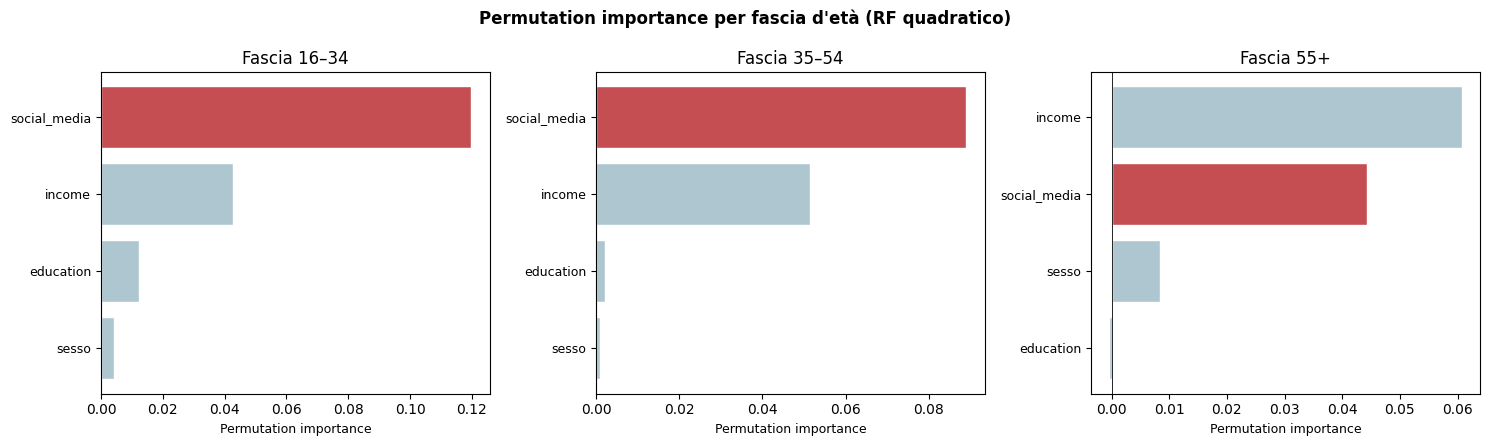

Salvato: output/figures/step4b_rf_importance_fascia.png


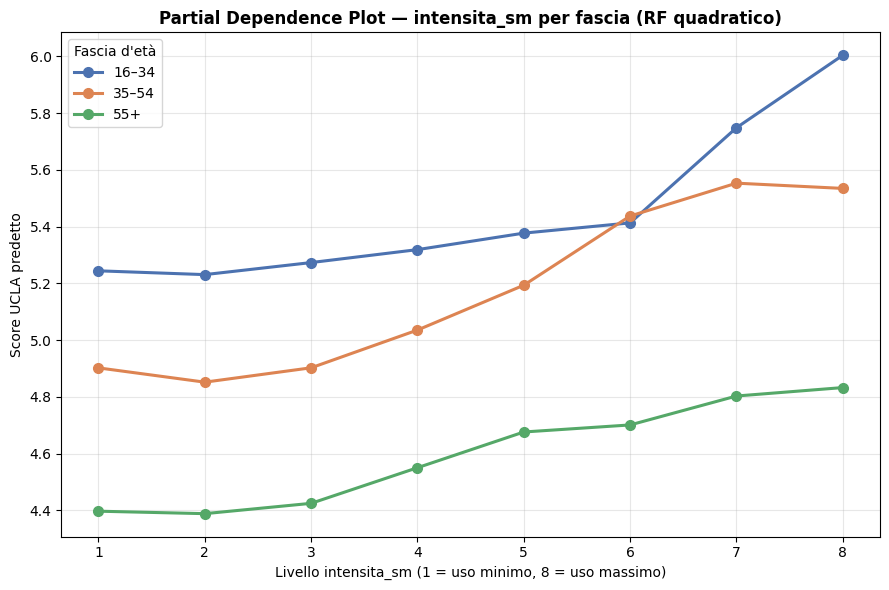

Salvato: output/figures/step4b_rf_pdp.png


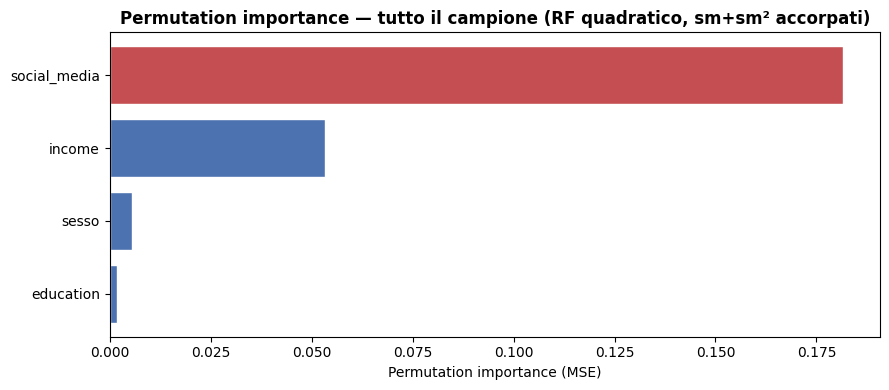

Salvato: output/figures/step4b_rf_importance_full.png

CONFRONTO: lineare (main) vs quadratico accorpato (robustness)

  Fascia    Lineare     Quadratico    Δ         Rank lin.   Rank quad.
  16–34         0.0287        0.1199   +0.0911  #2           #1
  35–54         0.0230        0.0891   +0.0661  #2           #1
  55+           0.0110        0.0444   +0.0334  #2           #2
  Full          0.0446        0.1817   +0.1371

[NB] La grouped permutation rompe sm+sm² insieme; produce magnitudini
     più alte ma forma del PDP equivalente al modello lineare.
     L'eterogeneità per età è coerente tra le due specificazioni.


In [5]:
# ============================================================
# STEP 4b - Robustness Check: RF con intensita_sm² (quadratico)
# ============================================================

# ------------------------------------------------------------------
# Permutation importance a blocchi
# ------------------------------------------------------------------
# Se le permutiamo separatamente, il modello recupera il segnale di sm tramite sm2 (correlate per costruzione), sottostimando entrambe.
# Permutarle insieme misura l'importanza del costrutto "social_media" nel complesso
def perm_importance_group(model, X, y, cols, n_repeats=10):
    baseline = mean_squared_error(y, model.predict(X))
    importances = []

    for _ in range(n_repeats):
        X_perm = X.copy()
        idx = np.random.permutation(len(X_perm))
        X_perm[cols] = X_perm[cols].iloc[idx].values
        perm_score = mean_squared_error(y, model.predict(X_perm))
        importances.append(perm_score - baseline)

    return np.mean(importances)

# ------------------------------------------------------------------
# Setup feature quadratico
# ------------------------------------------------------------------
# Aggiungiamo intensita_sm2 al feature set per il robustness check
df['intensita_sm2'] = df['intensita_sm'] ** 2

FEATURES_QUAD = ['intensita_sm', 'intensita_sm2', 'sesso', 'education', 'income']
X_quad = pd.concat([df[FEATURES_QUAD], paese_dummies], axis=1).astype(float)

# Dizionari per raccogliere modelli e importance del RF quadratico
modelli_quad  = {}
perm_imp_quad = {}

# RF per fascia
for fascia in fasce:
    mask = df['fascia_eta'] == fascia
    X_f  = X_quad[mask].reset_index(drop=True)
    y_f  = y[mask].reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_f, y_f, test_size=0.20, random_state=42)

    rf = RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    modelli_quad[fascia] = (rf, X_tr, X_te, y_tr, y_te)

    # Prima calcoliamo l'importance standard, poi la sostituiamo con quella a blocchi per sm e sm2 (importance classica)
    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
    imp_series = pd.Series(perm.importances_mean, index=X_quad.columns)

    # Importanza aggregata del blocco sm+sm2 e' il valore da confrontare con il modello lineare
    imp_social = perm_importance_group(
        rf, X_te, y_te, ['intensita_sm', 'intensita_sm2']
    )
    imp_series = imp_series.drop(['intensita_sm', 'intensita_sm2'])
    imp_series['social_media'] = imp_social

    perm_imp_quad[fascia] = imp_series

# RF full
X_tr_quad, X_te_quad, y_tr_quad, y_te_quad = train_test_split(
    X_quad, y, test_size=0.20, random_state=42)

rf_full_quad = RandomForestRegressor(
    n_estimators=200, max_features='sqrt',
    min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_full_quad.fit(X_tr_quad, y_tr_quad)

perm_full_quad = permutation_importance(
    rf_full_quad, X_te_quad, y_te_quad, n_repeats=10, random_state=42, n_jobs=-1)
imp_full_quad = pd.Series(perm_full_quad.importances_mean, index=X_quad.columns)

imp_social_full = perm_importance_group(
    rf_full_quad, X_te_quad, y_te_quad, ['intensita_sm', 'intensita_sm2']
)
imp_full_quad = imp_full_quad.drop(['intensita_sm', 'intensita_sm2'])
imp_full_quad['social_media'] = imp_social_full

# ------------------------------------------------------------------
# 4b.GRAFICO STANDALONE - Importance per fascia (3 pannelli)
# ------------------------------------------------------------------
# Grafico con grouped permutation e social_media supera income nelle fasce giovani
fig_imp_fascia_q, axes_q = plt.subplots(1, 3, figsize=(15, 4.5))
fig_imp_fascia_q.suptitle("Permutation importance per fascia d'età (RF quadratico)",
                          fontsize=12, fontweight='bold')

for ax, fascia in zip(axes_q, fasce):
    top5 = perm_imp_quad[fascia].drop(
        [c for c in perm_imp_quad[fascia].index if c.startswith('paese_')]
    ).nlargest(5).sort_values()
    colors = ['#C44E52' if f == 'social_media' else '#AEC6CF' for f in top5.index]
    ax.barh(top5.index, top5.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Fascia {fascia}')
    ax.set_xlabel('Permutation importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
fig_imp_fascia_q.savefig('output/figures/step4b_rf_importance_fascia.png',
                         dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4b_rf_importance_fascia.png")

# ------------------------------------------------------------------
# 4b.GRAFICO STANDALONE - PDP (RF quadratico)
# ------------------------------------------------------------------
# PDP del robustness check è praticamente identico al PDP lineare.
fig_pdp_q, ax_pdp_q = plt.subplots(figsize=(9, 6))

for fascia in fasce:
    rf, _, X_te, _, _ = modelli_quad[fascia]
    vals = []
    for v in range(1, 9):
        X_tmp = X_te.copy()
        X_tmp['intensita_sm']  = v
        X_tmp['intensita_sm2'] = v ** 2
        vals.append(rf.predict(X_tmp).mean())
    ax_pdp_q.plot(range(1, 9), vals, marker='o',
                  label=fascia, color=colori[fascia],
                  linewidth=2.2, markersize=7)

ax_pdp_q.set_title("Partial Dependence Plot — intensita_sm per fascia (RF quadratico)",
                   fontsize=12, fontweight='bold')
ax_pdp_q.set_xlabel('Livello intensita_sm (1 = uso minimo, 8 = uso massimo)')
ax_pdp_q.set_ylabel('Score UCLA predetto')
ax_pdp_q.set_xticks(range(1, 9))
ax_pdp_q.legend(title="Fascia d'età", fontsize=10)
ax_pdp_q.grid(alpha=0.3)

plt.tight_layout()
fig_pdp_q.savefig('output/figures/step4b_rf_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4b_rf_pdp.png")

# ------------------------------------------------------------------
# 4b.GRAFICO STANDALONE - Importance tutto il campione (sm+sm² accorpati)
# ------------------------------------------------------------------
# Grafico con importance globale con grouped permutation.
# Le magnitudini NON sono confrontabili col modello lineare (la grouped permutation produce valori piu' alti per costruzione)
fig_imp_full_q, ax_full_q = plt.subplots(figsize=(9, 4))

imp_ind_quad = imp_full_quad[['social_media', 'sesso', 'education', 'income']].sort_values()
colors_all_q = ['#C44E52' if f == 'social_media' else '#4C72B0'
                for f in imp_ind_quad.index]
ax_full_q.barh(imp_ind_quad.index, imp_ind_quad.values,
               color=colors_all_q, edgecolor='white')
ax_full_q.axvline(0, color='black', linewidth=0.6)
ax_full_q.set_title('Permutation importance — tutto il campione (RF quadratico, sm+sm² accorpati)',
                    fontsize=12, fontweight='bold')
ax_full_q.set_xlabel('Permutation importance (MSE)')

plt.tight_layout()
fig_imp_full_q.savefig('output/figures/step4b_rf_importance_full.png',
                       dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4b_rf_importance_full.png")

# ------------------------------------------------------------------
# CONFRONTO LINEARE vs QUADRATICO
# ------------------------------------------------------------------
print("\n" + "="*60)
print("CONFRONTO: lineare (main) vs quadratico accorpato (robustness)")
print("="*60)
print(f"\n  {'Fascia':8s}  {'Lineare':10s}  {'Quadratico':12s}  {'Δ':8s}  {'Rank lin.':10s}  {'Rank quad.'}")
for fascia in fasce:
    val_lin  = perm_imp[fascia]['intensita_sm']
    val_quad = perm_imp_quad[fascia]['social_media']
    rank_lin  = list(perm_imp[fascia].drop([c for c in perm_imp[fascia].index if c.startswith('paese_')]).sort_values(ascending=False).index).index('intensita_sm') + 1
    rank_quad = list(perm_imp_quad[fascia].drop([c for c in perm_imp_quad[fascia].index if c.startswith('paese_')]).sort_values(ascending=False).index).index('social_media') + 1
    print(f"  {fascia:8s}  {val_lin:10.4f}  {val_quad:12.4f}  {val_quad-val_lin:+8.4f}  #{rank_lin:<10d}  #{rank_quad}")

val_full_lin  = imp_full['intensita_sm']
val_full_quad = imp_full_quad['social_media']
print(f"  {'Full':8s}  {val_full_lin:10.4f}  {val_full_quad:12.4f}  {val_full_quad-val_full_lin:+8.4f}")

print("\n[NB] La grouped permutation rompe sm+sm² insieme; produce magnitudini")
print("     più alte ma forma del PDP equivalente al modello lineare.")
print("     L'eterogeneità per età è coerente tra le due specificazioni.")